# Introduction
In this notebook, various ways of plotting 3D information will be explored. The following will be covered:
-  Plot depth maps in 3D axes
- Try out Open3D
- Add Pose Points to 3D plots

Three images are goinf to be used for this example, one of a crashed car(car1.jpg), the UtahTeapot(0.3.jpg) and the ModedCube(33.jjpg). The images are located within the testImages directory.

# Plot depth maps in 3D axes

Using zoe-depth, depths maps of images will be first computed then plotted using Matplotlib.

The plot will be in 3 dimensions.

In [1]:
# Import Libraries
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize
import matplotlib.pyplot as plt
import cv2
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec


# Load the ZoeD_N pretrained Model
conf = get_config("zoedepth", "infer")
zoe = build_model(conf)

# Define Helper Functions

def load_image(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def load_image_gray(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.imread(img_dir+img_name, cv2.IMREAD_GRAYSCALE)

def compute_depth(image, dev="cpu"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    DEVICE = "cuda" if dev == "cuda" and torch.cuda.is_available() else "cpu"
    zoe.to(DEVICE)
    depth_numpy = zoe.infer_pil(image)  # as numpy
    zoe.to('cpu')
    torch.cuda.empty_cache()  # Clear unused cached memory
    return depth_numpy

def pixel_to_3d_point(u, v, depth, fx, fy, cx, cy):
    """
    Converts a pixel coordinate to a 3D point using depth and camera intrinsics.

    Args:
    u, v (int): Pixel coordinates.
    depth (float): Depth value at the pixel.
    fx, fy (float): Focal lengths of the camera in pixel units.
    cx, cy (float): Principal point coordinates.

    Returns:
    (float, float, float): The 3D coordinates of the point.
    """
    Z = depth
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy
    return (X, Y, Z)

def show_image(image, label, colorbar=True):
    """
    Display an image with an optional colorbar.

    Parameters:
    image : array-like
        The image data. This can be any array-like object that is interpretable by `imshow`.
    label : str
        The title label for the image. This text will be displayed above the image.
    colorbar : bool, optional
        A flag to indicate whether a colorbar should be displayed alongside the image.
        If True (default), a colorbar is displayed. If False, no colorbar is shown.

    """
    _, ax = plt.subplots(layout="constrained")
    imgPlot = ax.imshow(image)
    ax.set_title(label)
    if colorbar: plt.colorbar( imgPlot, ax=ax )

img_names = [ "car1.jpg", "33.jpg", "0.3.jpg" ] # list of images to be used
img_labels = ["Car", "Moded Cube", "Utah Teapot"]
depths = dict()

# Load the ZoeD_N pretrained Model
conf = get_config("zoedepth", "infer")
model_zoe_n = build_model(conf)

img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully
img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


<IPython.core.display.Javascript object>


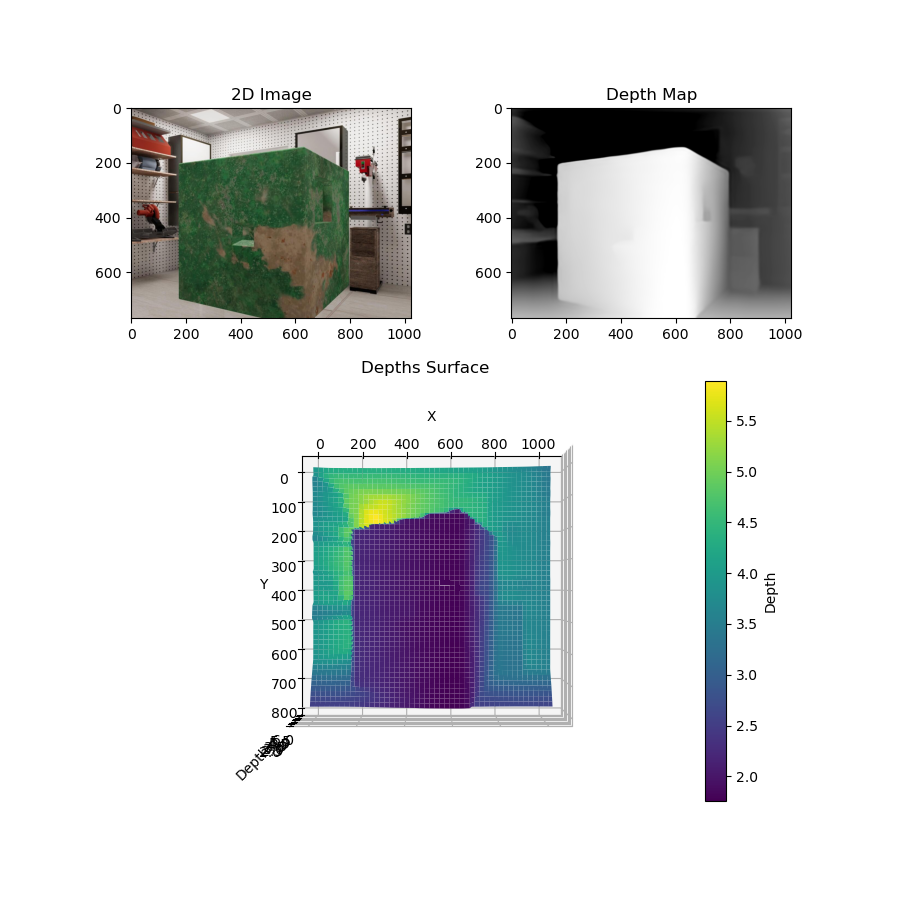

In [2]:
%matplotlib notebook
def depth_map_surface(img_name, label):
    image = load_image(img_name)
    depth_map = compute_depth(image)
    x = np.arange(depth_map.shape[1])
    y = np.arange(depth_map.shape[0])
    X,Y = np.meshgrid(x, y)
    
    # Create a figure with two subplots: one 2D and one 3D
    fig = plt.figure(figsize=(9,9), layout="constrained")

    # Create a gridspec with 2 rows and 2 columns
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1,2])


    axImg = fig.add_subplot(gs[0])
    axImg.imshow(image)
    axImg.set_title("2D Image")
    
    axDepth = fig.add_subplot(gs[1])
    axDepth.imshow(colorize(depth_map))
    axDepth.set_title("Depth Map")
    
    ax3d = fig.add_subplot(gs[2:4], projection='3d')
    # Plot the depth map as a 3D surface
    surface = ax3d.plot_surface(X, Y, depth_map, cmap='viridis') 
    ax3d.set_title(label)

    # Set axis labels
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Depth')
    ax3d.set_title("Depths Surface")
    ax3d.view_init(elev=-90, azim=-90, roll=None, vertical_axis='z')
    
    fig.colorbar(surface, ax=ax3d, orientation='vertical', pad=0.1, label='Depth')

    plt.show()
    
img = "33.jpg"
depth_map_surface("33.jpg", "Moded Cube")

# Open3D

[Open3D](open3d.org) is an open-source library that supports rapid development of software that deals with 3D data, providing a set of data structures and algorithms for working with 3D data.The backend is highly optimized and is set up for parallelization.

In [98]:
color_img = load_image("33.jpg")
depth_img = compute_depth(color_img)

## Creating Point Clouds from RGBD

In [116]:
# Import the Open3D library
import open3d as o3d

_scale = 1000
color_raw = o3d.geometry.Image(color_img)
depth_raw =  o3d.geometry.Image(depth_img*_scale)

# Create RGBD 
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, 
    depth_raw
)

# Camera Focal length
focal_l = 6
f_xy = focal_l *  color_img.shape[1]/6.287
cx, cy = ( color_img.shape[1]/2, color_img.shape[0]/2 )

# intrinsics = o3d.camera.PinholeCameraIntrinsic( o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)
intrinsics = o3d.camera.PinholeCameraIntrinsic(color_img.shape[1], color_img.shape[0], f_xy, f_xy, cx, cy)

# Create Point Cloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    intrinsics
)

print(f"Points : {len(pcd.points)}")

Points : 382249


### Modifying Views 

The o3d.visualization.draw_geometries() takes takes the following arguements which modify the perspective of the point cloud

**front**: This argument specifies the "front" direction of the camera. In other words, it defines the direction the camera is facing. It's a vector that points directly out of the camera's lens. The values you provide here determine which direction is considered the front or forward direction in the scene.

**lookat**: This argument sets the point in space that the camera is looking at. It's the focal point of the camera. When you set this parameter, you are effectively positioning the camera so that the lookat point is at the center of the camera's field of view. It's like when you point a camera at a specific object to make sure it's in the shot.

**up**: This argument defines the "up" direction in the scene relative to the camera's perspective. It's a vector that points upwards from the camera's point of view. Setting this vector helps to orient the camera by specifying which direction should be considered up in the visualization.

```
front = [0,0,-1]  # Camera is facing along the negative Z-axis
lookat = [0,0,0]  # Camera is looking at the origin
up = [0,1,0]      # The positive Y-axis is up
```

In [117]:
# Visualize the Point Cloud
o3d.visualization.draw_geometries([pcd],zoom=.1,
                                  front=[0, 0, -1],
                                  lookat=[0, 0, 0],
                                  up=[0, -1, 0])

`estimate_normals` computes the normal for every point. The function finds adjacent points and calculates the principal axis of the adjacent points using covariance analysis.

The function takes an instance of KDTreeSearchParamHybrid class as an argument. The two key arguments `radius` and `max_nn` specifies search radius and maximum nearest neighbor. It has 10cm of search radius, and only considers up to 30 neighbors to save computation time.

In [121]:
# Voxel Downsampling and Normal Calculation
downpcd = pcd.voxel_down_sample(voxel_size=.01)

downpcd.estimate_normals( search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=1, max_nn=20))
downpcd.orient_normals_towards_camera_location()

o3d.visualization.draw_geometries([downpcd], point_show_normal=False, zoom=1,
                                  front=[0, 0, -1],
                                  lookat=[0, 0, 0],
                                  up=[0, -1, 0])
print(f"Points: {len(downpcd.points)}")

Points: 50355


In [122]:
# Creating Bounding Volumes
bounding_boxa = downpcd.get_axis_aligned_bounding_box()
bounding_boxa.color = (1,0,0)

bounding_boxb = downpcd.get_oriented_bounding_box()
bounding_boxb.color = (0,0,1)


o3d.visualization.draw_geometries([downpcd, bounding_boxa, bounding_boxb],
                                  zoom=.1,
                                  front=[0, 0, -1],
                                  lookat=[0, 0, 0],
                                  up=[0, -1, 0])

## Clusering

Open3D implements DBSCAN [Ester1996] that is a density based clustering algorithm. The algorithm is implemented in cluster_dbscan and requires two parameters: `eps` defines the distance to neighbors in a cluster and `min_points` defines the minimum number of points required to form a cluster. The function returns labels, where the label -1 indicates noise.

In [130]:
with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    labels = np.array(
        pcd.cluster_dbscan(eps=0.09, min_points=100, print_progress=True))

max_label = labels.max()
print(f"point cloud has {max_label + 1} clusters")
colors = plt.get_cmap("tab20")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
pcd.colors = o3d.utility.Vector3dVector(colors[:, :3])
o3d.visualization.draw_geometries([pcd], zoom=.1,
                                  front=[0, 0, -1],
                                  lookat=[0, 0, 0],
                                  up=[0, -1, 0])

[Open3D DEBUG] Precompute neighbors.
Precompute neighbors.[========================================] 100%
[Open3D DEBUG] Done Precompute neighbors.                     ] 2%
[Open3D DEBUG] Compute Clusters
[Open3D DEBUG] Done Compute Clusters: 1
Precompute neighbors.[========================================] 100%
Clustering[========================>     point cloud has 1 clusters


# Using Masked Depth Maps

In [131]:
# Helper Functions
from rembg import remove, new_session
def create_mask(image):
    '''
        Create a Mask out of an image
    '''
    model_name = "u2net" # sam, u2net, silueta, isnet-general-use
    session = new_session(model_name)
    mask = remove(image, only_mask=True, post_process_mask=True)
    return mask
    
def mask_out(mask, _img):
    '''
        Masks out part of the image
    '''
    to_mask= np.copy(_img) # create a copy of the depth map
    to_mask[mask == 0] = 0
    return to_mask

EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecut

<IPython.core.display.Javascript object>


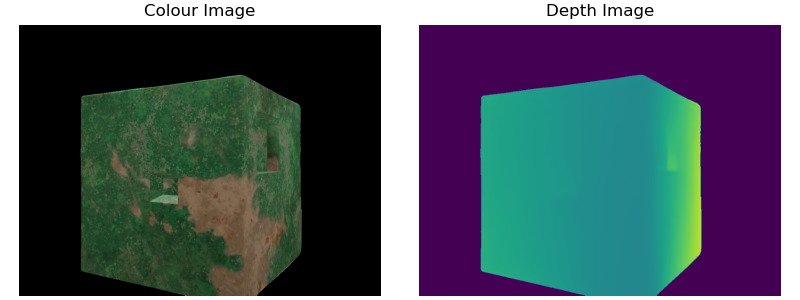

In [133]:
# Create a Depth Map
mask = create_mask(color_img)
masked_col = mask_out(mask, color_img)
masked_dep = mask_out(mask, depth_img)

fig, axs = plt.subplots( 1, 2, figsize=(8,3), layout="constrained" )
for title, ax, img in zip([ "Colour Image", "Depth Image" ], axs, [ masked_col, masked_dep ]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")


In [162]:
_scale = 1000
color_raw_m = o3d.geometry.Image(masked_col)
depth_raw_m =  o3d.geometry.Image(masked_dep*_scale) 

# Create RGBD 
rgbd_image_m = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw_m, 
    depth_raw_m
)

# Camera Focal length
focal_l = 6
f_xy = focal_l *  color_img.shape[1]/6.287
cx, cy = ( color_img.shape[1]/2, color_img.shape[0]/2 )

intrinsics = o3d.camera.PinholeCameraIntrinsic(color_img.shape[1], color_img.shape[0], f_xy, f_xy, cx, cy)

# Create Point Cloud
pcd2 = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image_m,
    intrinsics
)

# Voxel Downsampling and Normal Calculation
downpcd2 = pcd2.voxel_down_sample(voxel_size=.02)

downpcd2.estimate_normals( search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=.1, max_nn=30))
downpcd2.orient_normals_towards_camera_location()

# Creating Bounding Volumes
bba = downpcd2.get_axis_aligned_bounding_box()
bba.color = (1,0,0)

o3d.visualization.draw_geometries([downpcd2, bba], point_show_normal=False)

downpcd_p = np.asarray(downpcd2.points)
downpcd_n = np.asarray(downpcd2.normals)

print(f"Points: {len(downpcd2.points)} with shape: {downpcd_p.shape}")
print(f"Dimensions: { bba.get_extent() } ")

Points: 11681 with shape: (11681, 3)
Dimensions: [1.81895634 1.55875119 1.2468209 ] 


<IPython.core.display.Javascript object>


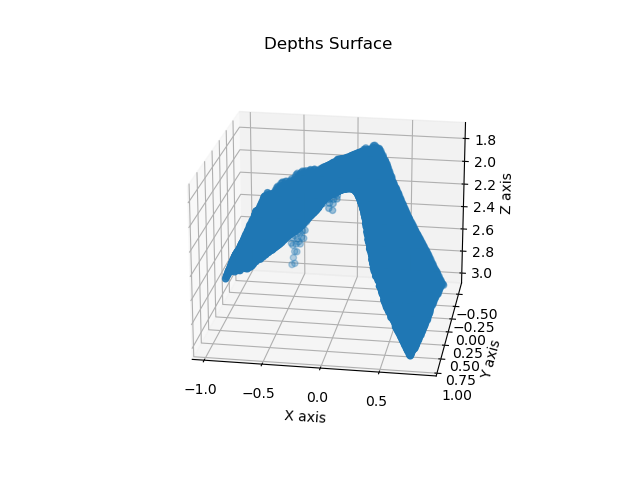

/tmp/ipykernel_4625/2909124263.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, z, cmap='viridis')


In [157]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


def plot_3d_points_with_colormap(points):
    """
    Plots a 3D point cloud with a color map based on Z-axis values.
    
    Args:
    points (numpy.ndarray): A NumPy array of shape (_, 3), where each row represents a 3D point (x, y, z).
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Extracting x, y, and z coordinates
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    
    # Creating a color map based on z-axis values
    colormap = ax.scatter(x, y, z, c=z, cmap='viridis')

    # Setting labels
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')

    # Adding a color bar as a legend for Z values
    cbar = fig.colorbar(colormap)
    cbar.set_label('Z value')

    # Show the plot
    plt.show()

    
# Example usage
plot_3d_points(downpcd_p)


SyntaxError: unmatched ')' (911812994.py, line 1)